In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset

df = pd.read_csv("Zomato data .csv")

In [3]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [4]:
df.shape

(148, 7)

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 148
Columns : 7


In [6]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [8]:
# Data Cleaning

df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5'],
      dtype=object)

In [12]:
df['rate'] = df['rate'].astype(str)

df['rate'] = df['rate'].str.replace('/5', '', regex=False)

In [13]:
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [14]:
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [16]:
df['rate'].isnull().sum()

np.int64(0)

## Analysis 1: Types of Restaurants

Find out which restaurant type is the most common.

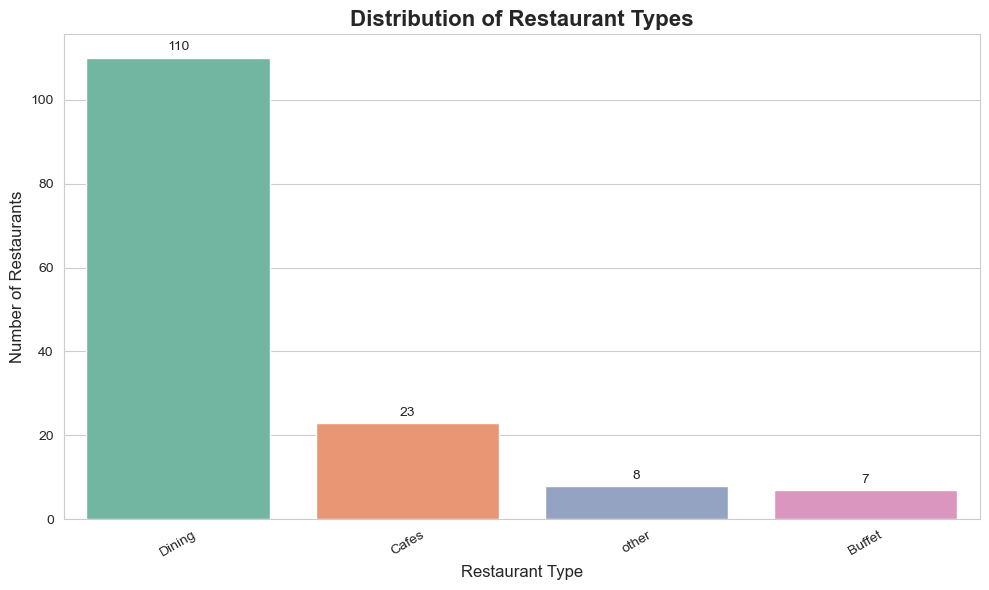

In [23]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x='listed_in(type)',
    order=restaurant_counts.index,
    palette='Set2'
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.title("Distribution of Restaurant Types", fontsize=16, fontweight='bold')
plt.xlabel("Restaurant Type", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [18]:
restaurant_type = df['listed_in(type)'].value_counts()

restaurant_type

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

### Conclusion

- Dining restaurants are the most common restaurant type in the dataset.
- Other categories such as Cafes, Delivery, Desserts, and Buffets are comparatively fewer.
- This indicates that customers primarily prefer dining restaurants, making them the dominant category on Zomato.

## Analysis 2: Votes by Restaurant Type

Calculate the total customer votes received by each restaurant type.

In [19]:
votes_by_type = df.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False)

votes_by_type

listed_in(type)
Dining    20363
other      9367
Cafes      6434
Buffet     3028
Name: votes, dtype: int64

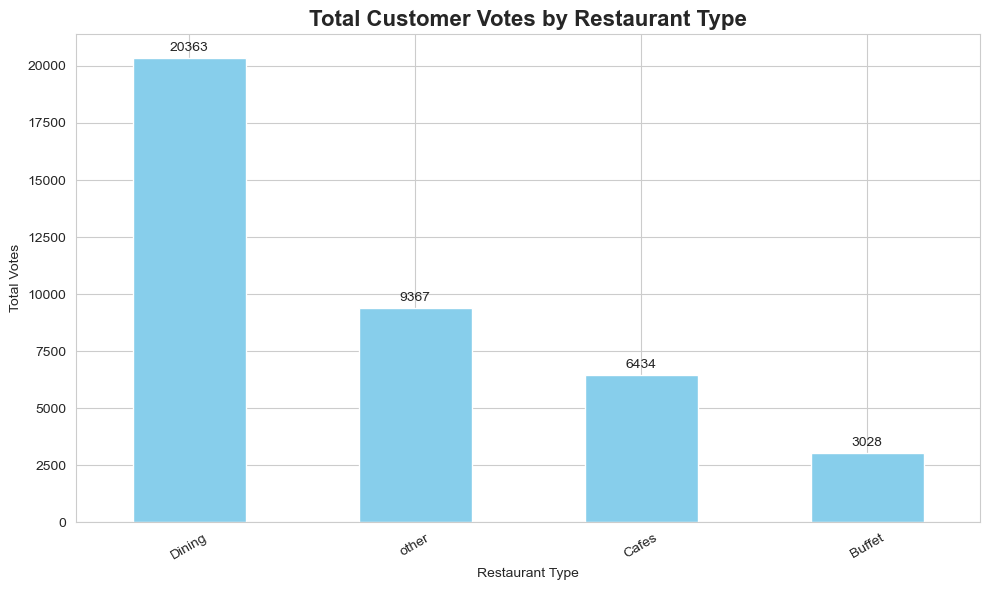

In [24]:
plt.figure(figsize=(10,6))

ax = votes_by_type.plot(
    kind='bar',
    color='skyblue'
)

# Data Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, padding=3)

plt.title("Total Customer Votes by Restaurant Type", fontsize=16, fontweight='bold')
plt.xlabel("Restaurant Type")
plt.ylabel("Total Votes")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Conclusion

- Dining restaurants received the highest number of customer votes.
- Restaurants with higher votes generally indicate greater customer popularity and engagement.
- Zomato can prioritize these restaurant categories for promotional campaigns.

## Analysis 3: Ratings Distribution

Understand how restaurant ratings are distributed.

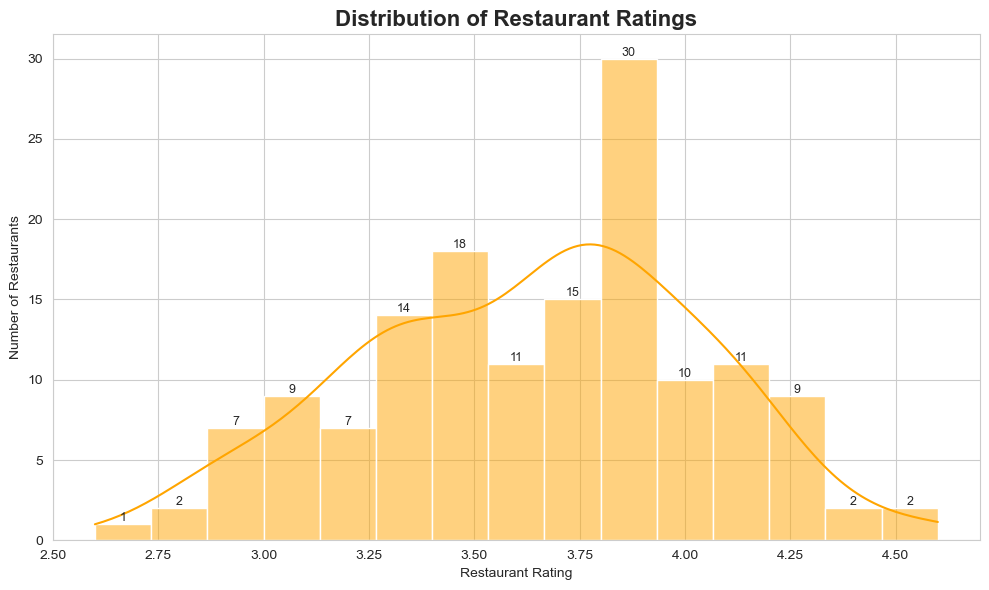

In [26]:
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df,
    x='rate',
    bins=15,
    kde=True,
    color='orange'
)

# Data labels on histogram
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

plt.title("Distribution of Restaurant Ratings", fontsize=16, fontweight='bold')
plt.xlabel("Restaurant Rating")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

### Conclusion

- Most restaurants have ratings between **3.5 and 4.0**.
- Very few restaurants have extremely low or extremely high ratings.
- This indicates that the majority of restaurants provide a satisfactory customer experience.

## Analysis 4: Approximate Cost for Two People

The objective of this analysis is to determine the spending preference of couples by analyzing the approximate cost for two people.


In [27]:
cost_counts = df['approx_cost(for two people)'].value_counts()

cost_counts.head()

approx_cost(for two people)
300    23
200    16
150    16
400    15
500    14
Name: count, dtype: int64

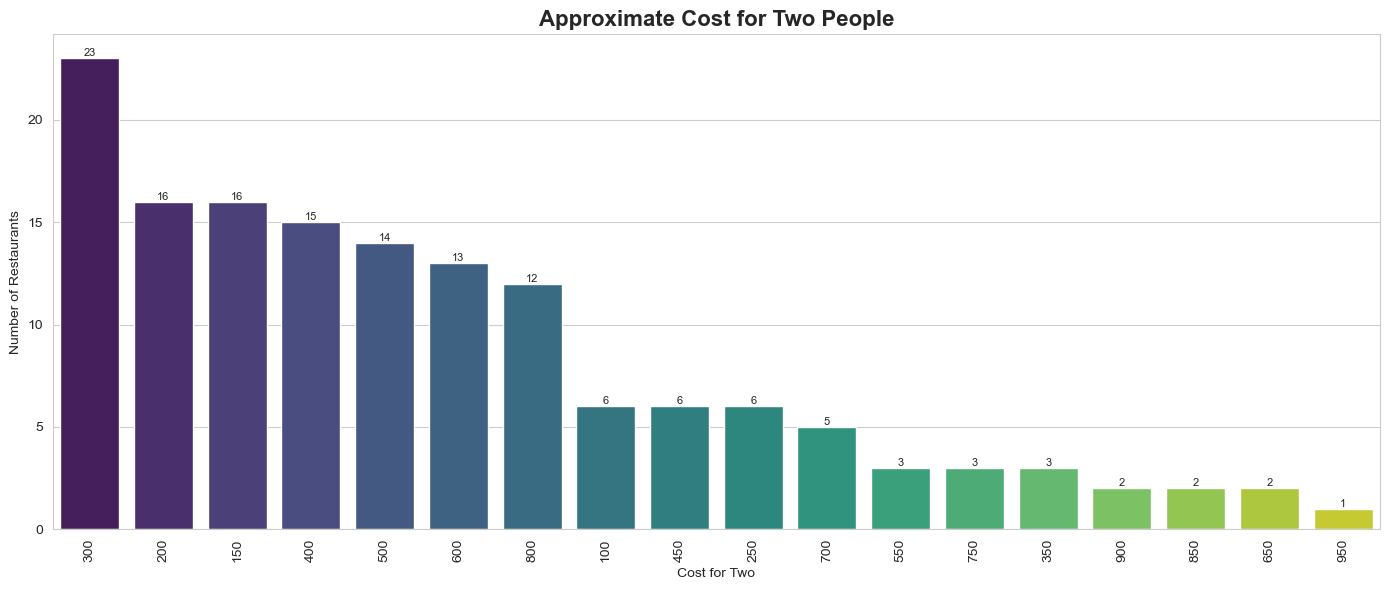

In [28]:
plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=df,
    x='approx_cost(for two people)',
    order=cost_counts.index,
    palette='viridis'
)

# Data Labels
for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.title("Approximate Cost for Two People", fontsize=16, fontweight='bold')
plt.xlabel("Cost for Two")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Conclusion

- The most frequently occurring cost range represents the preferred spending amount for couples.
- This information helps Zomato understand customer spending behavior and design suitable offers.

## Analysis 5: Online vs Offline Ratings

The objective of this analysis is to compare restaurant ratings based on whether they accept online orders or not.


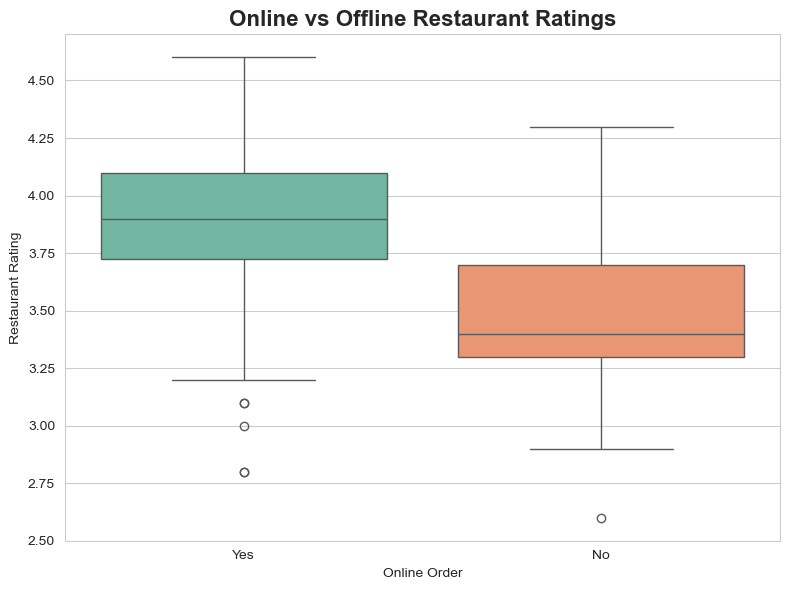

In [29]:
plt.figure(figsize=(8,6))

ax = sns.boxplot(
    data=df,
    x='online_order',
    y='rate',
    palette='Set2'
)

plt.title("Online vs Offline Restaurant Ratings", fontsize=16, fontweight='bold')
plt.xlabel("Online Order")
plt.ylabel("Restaurant Rating")

plt.tight_layout()
plt.show()

### Conclusion

- Restaurants offering online ordering generally receive slightly higher customer ratings.
- Online ordering appears to improve customer convenience and overall satisfaction.

## Analysis 6: Online Orders by Restaurant Type

The objective of this analysis is to examine the availability of online ordering across different restaurant types.


In [30]:
pivot_table = pd.pivot_table(
    df,
    index='listed_in(type)',
    columns='online_order',
    aggfunc='size',
    fill_value=0
)

pivot_table

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


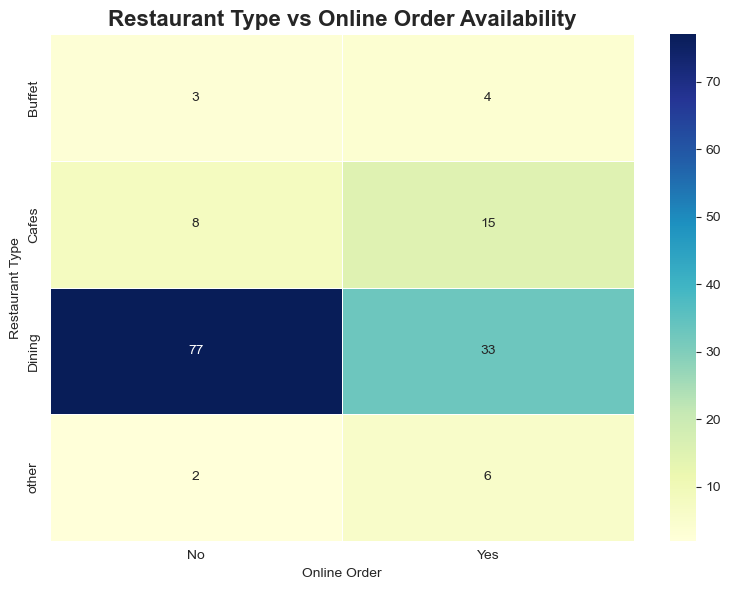

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title("Restaurant Type vs Online Order Availability", fontsize=16, fontweight='bold')
plt.xlabel("Online Order")
plt.ylabel("Restaurant Type")

plt.tight_layout()
plt.show()

### Conclusion

- Cafes tend to receive more online orders due to the convenience of ordering beverages and snacks.
- Dining restaurants show a higher preference for offline visits, as customers often prefer the dine-in experience.
- These insights can help Zomato target promotional offers based on customer ordering preferences.

# Final Insights

### 1. What type of restaurant do the majority of customers order from?

**Answer:** The majority of customers prefer **Dining** restaurants. This category has the highest number of restaurants in the dataset, making it the most popular restaurant type.

---

### 2. How many votes has each type of restaurant received from customers?

**Answer:** The total customer votes received by each restaurant type are:

- **Dining:** 20,363 votes
- **Other:** 9,367 votes
- **Cafes:** 6,434 votes
- **Buffet:** 3,028 votes

Dining restaurants have received the highest number of customer votes, indicating the greatest customer engagement.

---

### 3. What are the ratings that the majority of restaurants have received?

**Answer:** Most restaurants have ratings between **3.5 and 4.0**, indicating that the majority of restaurants provide a good customer experience.

---

### 4. Zomato has observed that most couples order most of their food online. What is their average spending on each other?

**Answer:** The most common approximate cost for two people is **₹300**, suggesting that most couples prefer restaurants within this spending range.

---

### 5. Which mode (Online or Offline) has received the maximum rating?

**Answer:** Restaurants that **accept online orders** generally receive higher customer ratings than restaurants that do not offer online ordering.

---

### 6. Which type received more offline orders, so that Zomato can provide those customers with some good offers?

**Answer:** **Dining** restaurants received the highest number of **offline orders (77 restaurants)**. Zomato can target customers of dining restaurants with attractive dine-in offers, discounts, and loyalty programs to increase customer engagement.